# Lab 04: The Scaling Relation That Depends on How You Fit It

**ASTR 457, Fall 2026, posted Thu Sep 24, due Wed Sep 30 by Noon (fork → PR, as always)**

**Extra credit, +5 points on this lab:** if you attended Charlotte Ward's Sep 22 Astronomy Colloquium, turn in at least a page of notes including two questions you had, as a text file in your `submissions/<netid>/` folder, by Noon Tue Sep 29.

*Why this lab: every scaling relation you will ever use ($M_{\rm BH}$–$\sigma$, Tully–Fisher, the mass–metallicity relation, the SN Ia standardization) was fit by someone who chose a regression method, and the choice changes the published slope. Knowing when ordinary least squares lies, by how much, and what to do instead is how you read those papers, and how you referee them.*

Every one of you has your own dataset: `data/<your netid>.csv`, a sample of dwarf
galaxies hosting active galactic nuclei, selected by their optical variability in the
style of Ward et al. (2022, arXiv:2110.13098). Dwarf-galaxy AGN are one of the few
windows we have on black holes in the $10^5$–$10^7\,M_\odot$ range, where the seeds of
supermassive black holes hide. Columns:

- `logMstar`, `err_logMstar`: $x = \log_{10}(M_*/M_\odot)$, the host stellar mass from
  SED fitting, and its $1\sigma$ uncertainty (0.2–0.4 dex; dwarf-galaxy photometry is hard),
- `logMBH`, `err_logMBH`: $y = \log_{10}(M_{\rm BH}/M_\odot)$, the virial black-hole
  mass from broad-line spectroscopy, and its $1\sigma$ uncertainty.

The relation you are after is

$$y = \alpha\,(x - 9.5) + \beta + \text{intrinsic scatter } \sigma_{\rm int},$$

pivoted at $M_* = 10^{9.5} M_\odot$ so $\alpha$ and $\beta$ don't fight each other. **Both
variables have measurement error, and the relation has real astrophysical scatter on top.**
I know your true $\alpha$, $\beta$, and $\sigma_{\rm int}$. You don't, your classmates'
values are different from yours, and so are your sample sizes.

**How this is graded.** Not on whether your code runs, but on whether your answers are
*right* and your uncertainties are *honest*. Part of your grade comes from how close your
reported $\alpha$ and $\beta$ are to your truth **in units of your own reported
uncertainty**. Tiny error bars you can't back up lose points; padded ones lose points too.
Calibration is the skill. The floor under "padded": your reported $\sigma_\alpha$ may not
exceed **3× the curvature uncertainty of your own generative fit** from Part 2 (if your
Hessian turns out singular, quote a profile-likelihood width instead and say so). Bigger
than that is not caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The fit everyone does first (15%)

Load your sample and plot it with error bars **on both axes**. Then fit the relation the
way most papers still do: **ordinary least squares** on $y$ vs $(x - 9.5)$, every point
weighted equally, errors ignored. Build the design matrix and solve the normal equations
yourself (lecture machinery, or `np.polyfit` if you must, but know what it's doing). Report
$\hat\alpha \pm \sigma$ using the standard OLS variance estimate, $s^2 (A^{\mathsf T}A)^{-1}$
with $s^2 = \mathrm{RSS}/(N-2)$ (residual-scaled; the errors play no role yet, on purpose).

Then answer, in a few sentences: which of OLS's assumptions does *your* dataset violate?
For the slope specifically, which way does the bias from the $x$-errors pull, and what
controls its size? (We named it in lecture on Sep 24. The effect is *supposed*
to be there; understanding exactly why, on your own data, is the point of this lab.)

OLS gives:

alpha:  1.18804 +/- 0.11875
beta:  6.65259 +/- 0.07907


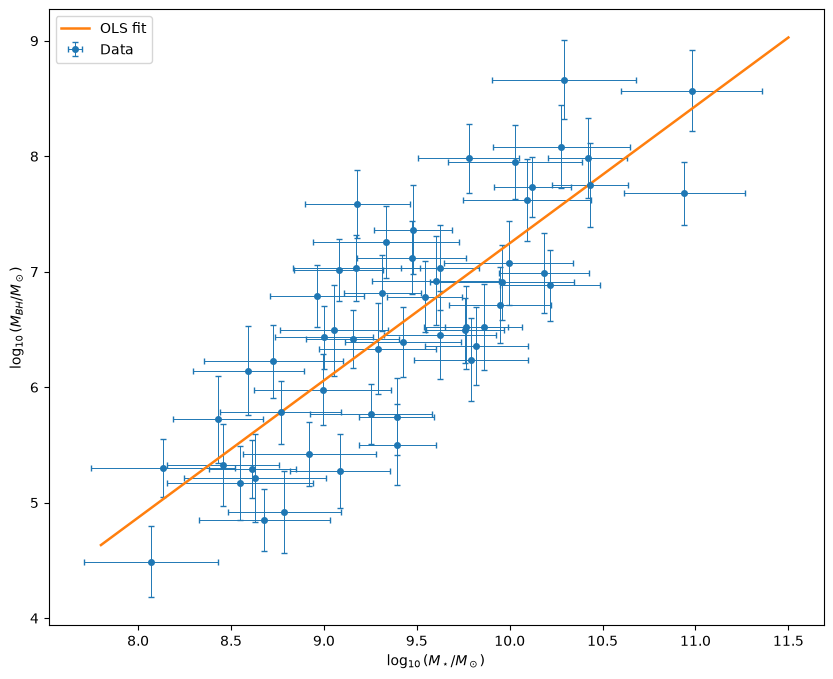

In [1]:
# Part 1: your work here
import numpy as np
import matplotlib.pyplot as plt


NETID = 'ratchev2'
d = np.genfromtxt(f'../../labs/04/data/{NETID}.csv', delimiter=',', names=True, skip_header=0)
x, y = d['logMstar'].astype(float), d['logMBH'].astype(float)
x_err, y_err = d['err_logMstar'].astype(float), d['err_logMBH'].astype(float)

A_design = np.vstack([np.ones(len(x)), x - 9.5]).T
AtA_inv = np.linalg.inv(A_design.T @ A_design)
theta = AtA_inv @ A_design.T @ y
resid = y - A_design @ theta
cov = (resid @ resid / (len(y) - 2)) * AtA_inv

print("OLS gives:")
print("")
print("alpha: ", round(theta[1], 5), "+/-", round(np.sqrt(cov[1, 1]), 5))
print("beta: ", round(theta[0], 5), "+/-", round(np.sqrt(cov[0, 0]), 5))

xx = np.linspace(7.8, 11.5, 100)
plt.figure(figsize = (10, 8))
plt.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='o', ms=4, elinewidth=0.7, capsize=2, label = "Data")
plt.plot(xx, theta[0] + theta[1] * (xx - 9.5), lw = 1.8, label = "OLS fit")
plt.xlabel(r"$\log_{10}(M_\star / M_\odot)$")
plt.ylabel(r"$\log_{10}(M_{BH} / M_\odot)$")
plt.legend()
plt.show()

**ANSWER (a few sentences):**

I obtained alpha = 1.18804 +/- 0.11875. However, OLS has multiple assumptions that my dataset violates. First, OLS assumes that x is measured exactly, but the x values here do have substantial uncertainties as can be seen in the plot above. Second, there is an intrinsic scatter to the data specified by sigma_int, and OLS does not take this into account at all. Lastly, the measurement uncertainties in y are not constant and instead vary point to point, while OLS assumes some constant residual variance. When it comes to the slope measurement, the most impactful bias is that of the measurement error in x that is not accounted for (not taking into account x uncertainties), which results in attenuation bias that decreases the OLS slope. This bias towards a slope of 0 is controlled in size by the ratio of the errors in the x data to the standard deviation of the true x values.

## Part 2: Estimators you can defend (40%)

Now fit the relation **three more ways** and compare:

1. **Weighted least squares** using the $y$-errors only:
   $\hat{\theta} = (A^{\mathsf T}\Sigma^{-1}A)^{-1}A^{\mathsf T}\Sigma^{-1}y$ with
   $\Sigma = \mathrm{diag}(\sigma_{y,i}^2)$, parameter covariance
   $(A^{\mathsf T}\Sigma^{-1}A)^{-1}$. Does weighting fix the Part 1 bias? Why or why not?

2. **Orthogonal distance regression** (`scipy.odr`, which warns that it is deprecated on
   import; that is fine in the course environment), which knows about the $x$-errors.
   Read what it minimizes before you run it. What does ODR assume about scatter
   *perpendicular to the relation*, and is that assumption true here?

3. **The generative model, honestly.** Write down where each data point comes from:
   the true stellar masses are drawn from the population,
   $x_i^{\rm true} \sim \mathcal{N}(\mu, \sigma_{\rm pop}^2)$; the relation plus intrinsic scatter
   makes the true BH mass; and your measurement errors corrupt both. Marginalizing over
   the (unobservable) true masses makes each observed pair $(x_i, y_i)$ a **bivariate
   Gaussian**:

   $$\begin{pmatrix} x_i \\ y_i \end{pmatrix} \sim \mathcal{N}\!\left[
   \begin{pmatrix} \mu \\ \alpha(\mu - 9.5) + \beta \end{pmatrix},\;
   \begin{pmatrix} \sigma_{\rm pop}^2 + \sigma_{x,i}^2 & \alpha\,\sigma_{\rm pop}^2 \\
   \alpha\,\sigma_{\rm pop}^2 & \alpha^2\sigma_{\rm pop}^2 + \sigma_{\rm int}^2 + \sigma_{y,i}^2 \end{pmatrix}
   \right]$$

   (Convince yourself of the three variance entries before you code; the off-diagonal
   covariance is what removes the attenuation bias. This is the Gaussian core of Kelly 2007, the paper behind
   every modern `linmix`-style fit.) Maximize the summed log-likelihood over all five
   parameters $(\alpha, \beta, \sigma_{\rm int}, \mu, \sigma_{\rm pop})$, and get uncertainties from
   the curvature of the log-likelihood at its peak (the observed information), and say so.

Make **one plot with all four fitted lines overplotted** on your data. They will not agree.
Explain, estimator by estimator, *why* each lands where it does, and which ingredient of the
data each one ignores.

Commit to a **final answer**: one $\alpha \pm \sigma$, $\beta \pm \sigma$, and
$\sigma_{\rm int} \pm \sigma$ you'd put in a paper, and justify the choice. Remember the
3× rule from the header.

WLS (using y errors only) gives:

alpha:  1.1738 +/- 0.06387
beta:  6.66107 +/- 0.0433


C:\Users\Dante\AppData\Local\Temp\ipykernel_114476\2924862690.py:14: DeprecationWarning: `scipy.odr` is deprecated as of version 1.17.0 and will be removed in SciPy 1.19.0. Please use `https://pypi.org/project/odrpack/` instead.
  from scipy import stats, odr



ODR gives:

alpha:  1.55403 +/- 0.15153
beta:  6.6666 +/- 0.08687

The generative model gives:

alpha:  1.44947 +/- 0.16496
beta:  6.6557 +/- 0.0846
sigma_int:  0.33358 +/- 0.10589


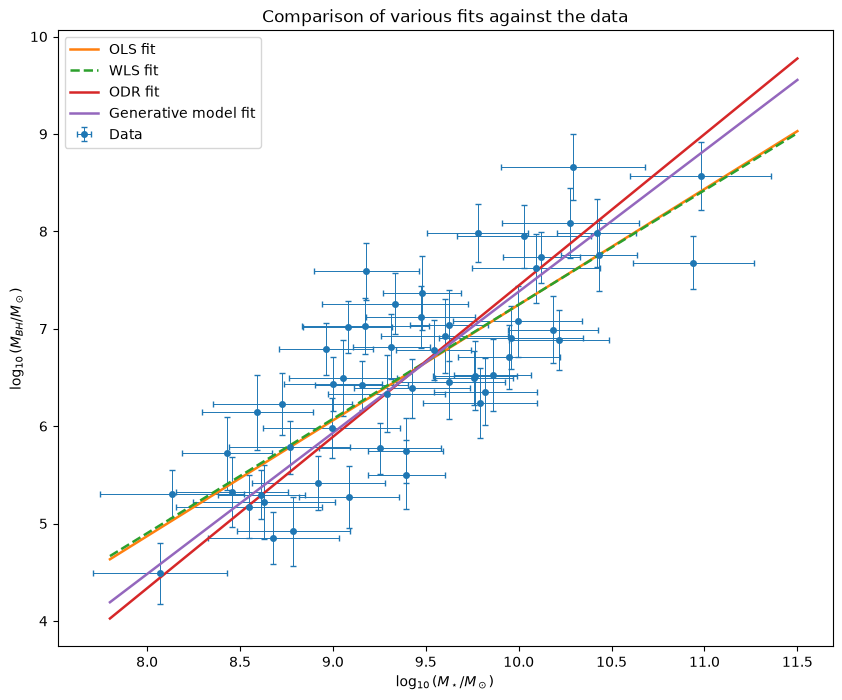

In [2]:
# Part 2: your work here

# 1. Weighted least squares
Si_wls = np.linalg.inv(np.diag(y_err**2))
cov_wls = np.linalg.inv(A_design.T @ Si_wls @ A_design)
theta_wls = cov_wls @ A_design.T @ Si_wls @ y

print("WLS (using y errors only) gives:")
print("")
print("alpha: ", round(theta_wls[1], 5), "+/-", round(np.sqrt(cov_wls[1, 1]), 5))
print("beta: ", round(theta_wls[0], 5), "+/-", round(np.sqrt(cov_wls[0, 0]), 5))

# 2. Orthogonal Distance Regression
from scipy import stats, odr

def line_model(A, x):
    return A[0] * (x - 9.5) + A[1]

odr = odr.ODR(odr.RealData(x, y, sx = x_err, sy = y_err), odr.Model(line_model), beta0 = [1.1, 6.6])
odr_out = odr.run()
alpha_odr, beta_odr = odr_out.beta
alpha_odr_err, beta_odr_err = odr_out.sd_beta

print("")
print("ODR gives:")
print("")
print("alpha: ", round(alpha_odr, 5), "+/-", round(alpha_odr_err, 5))
print("beta: ", round(beta_odr, 5), "+/-", round(beta_odr_err, 5))

# 3. Generative Model
from scipy.optimize import minimize
def neg_log_likelihood(z0, x = x, y = y, sx = x_err, sy = y_err):
    alpha, beta, log_sigma_int, mu, log_sigma_pop = z0
    var_int = np.exp(2 * log_sigma_int)
    var_pop = np.exp(2 * log_sigma_pop)

    dx = x - mu
    dy = y - (alpha * (mu - 9.5) + beta)

    cov_matrix_11 = var_pop + sx**2
    cov_matrix_12 = alpha * var_pop
    cov_matrix_21 = alpha * var_pop
    cov_matrix_22 = alpha**2 * var_pop + var_int + sy**2

    det = cov_matrix_11 * cov_matrix_22 - cov_matrix_12 * cov_matrix_21
    rT_invcov_r = (cov_matrix_22 * dx**2 - 2 * cov_matrix_12 * dx * dy + cov_matrix_11 * dy**2) / det
    return np.sum(np.log(det) + rT_invcov_r)

# hessian
z0 = [alpha_odr, beta_odr, np.log(0.3), x.mean(), np.log(x.std())]
res = minimize(neg_log_likelihood, z0, method = 'Nelder-Mead')

h = 1e-4
n = len(res.x)
hess = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        ei, ej = np.zeros(n), np.zeros(n)
        ei[i] = h; ej[j] = h
        hess[i, j] = (neg_log_likelihood(res.x + ei + ej) - neg_log_likelihood(res.x + ei - ej)
                          - neg_log_likelihood(res.x - ei + ej) + neg_log_likelihood(res.x - ei - ej)) / (4 * h**2)

theta_gen = res.x
err_gen = np.sqrt(np.diag(2 * np.linalg.inv(hess)))
sigma_int = np.exp(theta_gen[2])
sigma_int_err = sigma_int * err_gen[2] # i do this here because the error is in log space so I need to use error propagation to get it to be normal

print("")
print("The generative model gives:")
print("")
print("alpha: ", round(theta_gen[0], 5), "+/-", round(err_gen[0], 5))
print("beta: ", round(theta_gen[1], 5), "+/-", round(err_gen[1], 5))  
print("sigma_int: ", round(sigma_int, 5), "+/-", round(sigma_int_err, 5))

xx = np.linspace(7.8, 11.5, 100)
plt.figure(figsize = (10, 8))
plt.errorbar(x, y, xerr=x_err, yerr=y_err, fmt='o', ms=4, elinewidth=0.7, capsize=2, label = "Data")
plt.plot(xx, theta[0] + theta[1] * (xx - 9.5), lw = 1.8, label = "OLS fit")
plt.plot(xx, theta_wls[0] + theta_wls[1] * (xx - 9.5), lw = 1.8, ls = '--', label = "WLS fit")
plt.plot(xx, beta_odr + alpha_odr * (xx - 9.5), lw = 1.8, label = "ODR fit")
plt.plot(xx, theta_gen[1] + theta_gen[0] * (xx - 9.5), lw = 1.8, label = "Generative model fit")
plt.xlabel(r"$\log_{10}(M_\star / M_\odot)$")
plt.ylabel(r"$\log_{10}(M_{BH} / M_\odot)$")
plt.legend()
plt.title("Comparison of various fits against the data")
plt.show()

**FINAL ANSWER:** $\alpha = $ 1.44947 $\pm$ 0.16496 , $\beta = $ 6.6557 $\pm$ 0.0846 , $\sigma_{\rm int} = $ 0.33358 $\pm$ 0.10589 dex

**Justification and uncertainty method (a short paragraph):**

The four estimators all give different slopes because they make different assumptions both about the measurement errors in x and y but also the presence of intrinsic scatter in the data. OLS gives alpha = 1.18804 +/- 0.11875, and as I mentioned in Part 1, this is not a very trustworthy result due to the fact that OLS ignores the given measurement uncertainties as well as potential instrinsic scatter in the data. The most major impact of the assumptions of OLS comes from the fact that it treats x values as exact when in fact there are large measurement uncertainties in x. These unaccounted for measurement uncertainties result in attenuation bias that pulls the slope towards 0. Weighted least squares gives a very similar result of alpha = 1.1738 +/- 0.06387, because while it does factor in the different y uncertainties, it still treats x as exact and therefore does not fix the Part 1 bias with OLS. ODR gives a steeper slope of alpha = 1.55403 +/- 0.15153 while accounting for both x and y errors. However, it suffers its own problems. ODR assumes that the scatter in the data is perpendicular to the fitted relation. This assumption is not true here because while the data does have scatter due to measurement errors in both x and y, the true relation is characterized by intrinsic scatter in the y direction at fixed true x values. ODR suffers from a steeper slope because each residual is divided by sqrt(sigma_y^2 + alpha^2 * sigma_x^2) and so a steeper line makes this bigger and therefore chi_2 smaller, and ODR is incapable of modelling the true x values. Finally, the generative model gives alpha = 1.44947 +/- 0.16496, beta = 6.6557 +/- 0.0846, and sigma_int = 0.33358 +/- 0.10589 which has a slope that falls between all of the other options. This model factors in not only the measurement errors in both variables, but also the standard deviation of the masses of the original population and the intrinsic scatter in y. By calculating uncertainty through a non-diagonal correlation matrix where the correlation between x and y values is accounted for via the alpha sigma_pop^2 terms, we are able to fully account for the underlying mass population distribution and thus obtain a result with much less assumptions. More specifically, the uncertainties are obtained from the curvature of the maximum of the -2logL surface using the inverse of a numerical Hessian. This results in an uncertainty on the slope of 0.16496, where we can see that none of the estimators exceed 3 times this number. Overall, the generative model doesn't assume exact x values like OLS and WLS and doesn't fail to account for intrinsic scatter like ODR, while also accounting for the initial population of masses. This makes its results the best choice.

## Part 3: The verification plan, written first and then executed (35%)

**Before you run anything below, write the plan** (3a). A verification plan you invent
after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the generative recipe in
   Part 2 tells you exactly how) and confirm your fit recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot each estimator's bias and variance for $\alpha$. This is
   *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time, for all three reported parameters?
4. **Sensitivity**: what happens to $\hat\alpha$ if the catalog $x$-errors are wrong by
   ±50% (generate correctly, fit with the mis-stated errors)? If the true population isn't Gaussian (try drawing $x^{\rm true}$ from a uniform
   distribution with the same mean and variance instead)? If you had assumed $\sigma_{\rm int} = 0$?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

1. Closure: I will simulate a dataset using the generative model I used for part 2 with realistic values of all 5 parameters and then check that I recover those parameters. More specifically, I will generate the stellar masses from a population distribution, generate the true BH masses using the intrinsic scatter, and then add measurement errors on top. I will then fit this with the model I used for part 2. Failure would look like any of the parameters being farther away from the value used to generate the dataset by multiple times the uncertainty.

2. Bias and Efficiency: I will perform a Monte Carlo simulation using many simulated datasets with parameters near those from the real data. For each of these datasets I will calculate the bias and variance for alpha of all of my estimators and use a plot to compare these values to each other. I would expect the atenuation bias in OLS and WLS to be clearly visible, with ODR and the generative fit having smaller amounts of bias. I also expect the generative fit in general to have the smallest bias from the real alpha value and to not have an unreasonably large variance compared to the other estimators. A failure here would be a large bias or inexplicably large variance in the generative fit compared to other estimators.

3. Coverage: For the estimators, I will use the uncertainty estimate to obtain a 68% interval and then take the Monte Carlo simulations and count the fraction of the simulations for which the alpha/beta/sigma_int values obtained are within this 68% interval. I will check to ensure that this is approximately 68% of the time. Failure would be clear by this percentage being much less or more than 68% for any of the 3 parameters.

4. Sensitivity: I will generate a dataset using the correct x errors but then fit them using x errors wrong by +/- 50%, and compare the resulting alpha values to the correct fitted result. There is not really a "failure" here, but a large change in alpha would mean that the slope is sensitive to the x-error calibration which could be seen as a failure/warning sign. I will then using a uniform distribution for the true x values rather than a Gaussian (using the same mean and variance) and compare alpha here with the correct fitted result. Again here, a large change would indicate that the slope is sensitive to the choice of distribution of the x values and so that assumption is very important. Finally, I will fit the data with the incorrect assumption that sigma_int is equal to 0 and compare alpha here with the correct result. A large change would indicate that the intrinsic scatter cannot be ignored, which is what we would expect. A failure therefore would be similar results to if we had explictly fitted this scatter.

Closure:
True alpha = 1.3
True beta = 7.8
True sigma_int = 0.3
True mu = 9.26
True sigma_pop = 0.6

Generative alpha = 1.26789 +/- 0.13656
Generative beta = 7.72414 +/- 0.08417
Generative sigma_int = 0.31782 +/- 0.10237
Generative mu = 9.28682 +/- 0.09658
Generative sigma_pop = 0.65486 +/- 0.07564

Bias and Efficiency
Bias:
OLS: -0.26185
WLS: -0.26427
ODR: 0.12492
Generative Model: 0.01842

Variance:
OLS: 0.01355
WLS: 0.0139
ODR: 0.02799
Generative Model: 0.02433


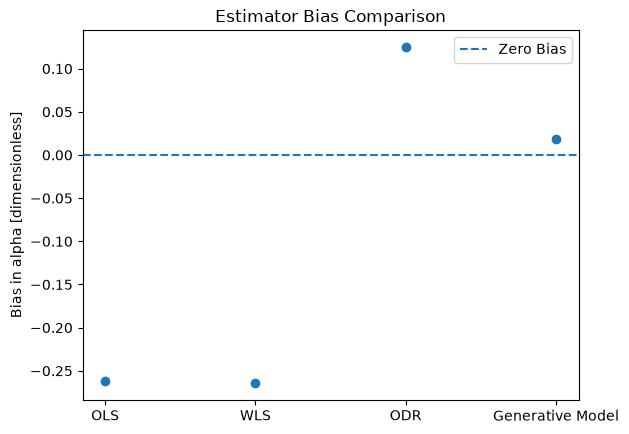

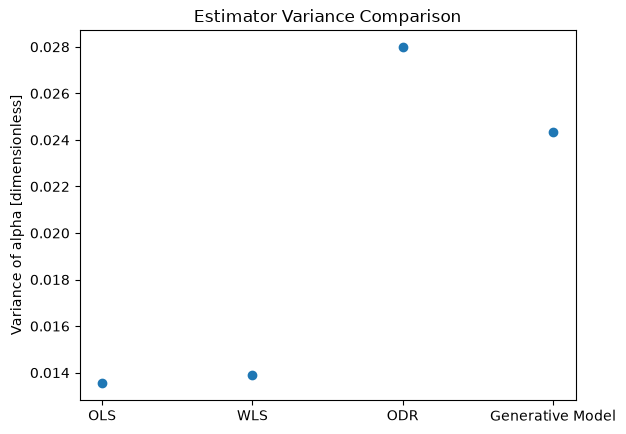


Coverage:
68% coverage:
Alpha = 0.69694
Beta = 0.6786
Sigma_int = 0.86625

Sensitivity
Sensitivity to x-error:
Alpha with correct x errors = 1.26789
Alpha with 50% smaller x errors = 1.08844
Alpha with 50% larger x errors = 1.49813
Alpha with uniform true population = 1.04855
Alpha with no sigma_int =  1.3671


In [3]:
# Part 3b: execute the plan here

# CLOSURE

real_alpha = 1.3
real_beta = 7.8
real_sigma_int = 0.3
real_mu = 9.26
real_sigma_pop = 0.6

r_num = np.random.default_rng(9999)
real_x = r_num.normal(real_mu, real_sigma_pop, len(x))
real_y = (real_alpha * (real_x - 9.5) + real_beta + r_num.normal(0, real_sigma_int, len(x)))
x_clos = real_x + r_num.normal(0, x_err)
y_clos = real_y + r_num.normal(0, y_err)

# hessian
z0_clos = [1.2, 6.9, np.log(0.35), x_clos.mean(), np.log(x_clos.std())]
res_clos = minimize(neg_log_likelihood, z0_clos, args = (x_clos, y_clos, x_err, y_err), method = 'Nelder-Mead')

h = 1e-4
n = len(res_clos.x)
hess_clos = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        ei, ej = np.zeros(n), np.zeros(n)
        ei[i] = h; ej[j] = h
        hess_clos[i, j] = (neg_log_likelihood(res_clos.x + ei + ej, x_clos, y_clos, x_err, y_err) - neg_log_likelihood(res_clos.x + ei - ej, x_clos, y_clos, x_err, y_err)
                          - neg_log_likelihood(res_clos.x - ei + ej, x_clos, y_clos, x_err, y_err) + neg_log_likelihood(res_clos.x - ei - ej, x_clos, y_clos, x_err, y_err)) / (4 * h**2)

theta_gen_clos = res_clos.x
alpha_clos = theta_gen_clos[0]
beta_clos = theta_gen_clos[1]
mu_clos = theta_gen_clos[3]
err_gen_clos = np.sqrt(np.diag(2 * np.linalg.inv(hess_clos)))
sigma_int_clos = np.exp(theta_gen_clos[2])
sigma_int_clos_err = sigma_int_clos * err_gen_clos[2]
sigma_pop_clos = np.exp(theta_gen_clos[4])
sigma_pop_clos_err = sigma_pop_clos * err_gen_clos[4]
alpha_clos_err = err_gen_clos[0]
beta_clos_err = err_gen_clos[1]
mu_clos_err = err_gen_clos[3]

print("Closure:")
print("True alpha =", round(real_alpha, 5))
print("True beta =", round(real_beta, 5))
print("True sigma_int =", round(real_sigma_int, 5))
print("True mu =", round(real_mu, 5))
print("True sigma_pop =", round(real_sigma_pop, 5))
print("")
print("Generative alpha =", round(alpha_clos, 5), "+/-", round(alpha_clos_err,5))
print("Generative beta =", round(beta_clos, 5), "+/-", round(beta_clos_err,5))
print("Generative sigma_int =", round(sigma_int_clos, 5), "+/-", round(sigma_int_clos_err,5))
print("Generative mu =", round(mu_clos, 5), "+/-", round(mu_clos_err,5))
print("Generative sigma_pop =", round(sigma_pop_clos, 5), "+/-", round(sigma_pop_clos_err,5))

# BIAS AND EFFICIENCY
from scipy import odr
num_sims = 500
alpha_ols = np.empty(num_sims)
alpha_wls = np.empty(num_sims)
alpha_odr = np.empty(num_sims)
alpha_gen = np.empty(num_sims)

r_num = np.random.default_rng(9999)

for i in range(num_sims):
    x_true = r_num.normal(real_mu, real_sigma_pop, len(x))
    y_true = (real_alpha * (x_true - 9.5) + real_beta + r_num.normal(0, real_sigma_int, len(x)))
    x_obs = x_true + r_num.normal(0, x_err)
    y_obs = y_true + r_num.normal(0, y_err)

    A_sim = np.vstack([np.ones(len(x_obs)), x_obs - 9.5]).T
    AtA_inv_sim = np.linalg.inv(A_sim.T @ A_sim)
    theta_ols_sim = AtA_inv_sim @ A_sim.T @ y_obs
    alpha_ols[i] = theta_ols_sim[1]

    Si_wls_sim = np.linalg.inv(np.diag(y_err**2))
    cov_wls_sim = np.linalg.inv(A_sim.T @ Si_wls_sim @ A_sim)
    theta_wls_sim = cov_wls_sim @ A_sim.T @ Si_wls_sim @ y_obs
    alpha_wls[i] = theta_wls_sim[1]

    odr_sim = odr.ODR(odr.RealData(x_obs, y_obs, sx = x_err, sy = y_err), odr.Model(line_model), beta0 = [real_alpha, real_beta])
    odr_out_sim = odr_sim.run()
    alpha_odr[i] = odr_out_sim.beta[0]

    z0_sim= [real_alpha, real_beta, np.log(real_sigma_int), np.mean(x_obs), np.log(np.std(x_obs))]
    res_sim = minimize(neg_log_likelihood, z0_sim, args = (x_obs, y_obs, x_err, y_err), method = 'Nelder-Mead')
    alpha_gen[i] = res_sim.x[0]

ols_bias = np.mean(alpha_ols) - real_alpha
wls_bias = np.mean(alpha_wls) - real_alpha
odr_bias = np.mean(alpha_odr) - real_alpha
gen_bias = np.mean(alpha_gen) - real_alpha

ols_var = np.var(alpha_ols, ddof=1)
wls_var = np.var(alpha_wls, ddof=1)
odr_var = np.var(alpha_odr, ddof=1)
gen_var = np.var(alpha_gen, ddof=1)
print("")
print("Bias and Efficiency")
print("Bias:")
print("OLS:", round(ols_bias, 5))
print("WLS:", round(wls_bias, 5))
print("ODR:", round(odr_bias, 5))
print("Generative Model:", round(gen_bias, 5))

print("")
print("Variance:")
print("OLS:", round(ols_var, 5))
print("WLS:", round(wls_var, 5))
print("ODR:", round(odr_var, 5))
print("Generative Model:", round(gen_var, 5))

plt.scatter(["OLS", "WLS", "ODR", "Generative Model"], [ols_bias, wls_bias, odr_bias, gen_bias])
plt.axhline(0, linestyle="--", label="Zero Bias")
plt.ylabel("Bias in alpha [dimensionless]")
plt.title("Estimator Bias Comparison")
plt.legend()
plt.show()

plt.scatter(["OLS", "WLS", "ODR", "Generative Model"], [ols_var, wls_var, odr_var, gen_var])
plt.ylabel("Variance of alpha [dimensionless]")
plt.title("Estimator Variance Comparison")
plt.show()

# COVERAGE
print("")
print("Coverage:")

r_num = np.random.default_rng(9999)

num_sims = 5000
alpha_count = 0
beta_count = 0
sigma_int_count = 0
valid_sims = 0

for i in range(num_sims):
    x_true = r_num.normal(real_mu, real_sigma_pop, len(x))
    y_true = (real_alpha * (x_true - 9.5) + real_beta + r_num.normal(0, real_sigma_int, len(x)))
    x_obs = x_true + r_num.normal(0, x_err)
    y_obs = y_true + r_num.normal(0, y_err)
    z0_sim= [real_alpha, real_beta, np.log(real_sigma_int), np.mean(x_obs), np.log(np.std(x_obs))]
    res_sim = minimize(neg_log_likelihood, z0_sim, args = (x_obs, y_obs, x_err, y_err), method = 'Nelder-Mead')
    theta_sim = res_sim.x

    h = 1e-4
    n = len(theta_sim)
    hess_sim = np.zeros((n, n))
    for j in range(n):
        for k in range(n):
            ej, ek = np.zeros(n), np.zeros(n)
            ej[j] = h; ek[k] = h
            hess_sim[j, k] = (neg_log_likelihood(theta_sim + ej + ek, x_obs, y_obs, x_err, y_err) - neg_log_likelihood(theta_sim + ej - ek, x_obs, y_obs, x_err, y_err)
                              - neg_log_likelihood(theta_sim - ej + ek, x_obs, y_obs, x_err, y_err) + neg_log_likelihood(theta_sim - ej - ek, x_obs, y_obs, x_err, y_err)) / (4 * h**2)
    try: # here im just skipping times when this is a singular matrix to make this easier, also when there are negative diagonal elements
        cov_sim = 2 * np.linalg.inv(hess_sim)
        if not np.all((np.diag(cov_sim)) > 0):
            continue
    except np.linalg.LinAlgError:
        continue
    
    err_sim = np.sqrt(np.diag(cov_sim))
    valid_sims += 1

    if abs(theta_sim[0] - real_alpha) <= err_sim[0]:
        alpha_count += 1
    if abs(theta_sim[1] - real_beta) <= err_sim[1]:
        beta_count += 1
    if abs(np.exp(theta_sim[2]) - real_sigma_int) <= np.exp(theta_sim[2]) * err_sim[2]:
        sigma_int_count += 1

alpha_coverage = alpha_count / valid_sims
beta_coverage = beta_count / valid_sims
sigma_int_coverage = sigma_int_count / valid_sims

print("68% coverage:")
print("Alpha =", round(alpha_coverage, 5))
print("Beta =", round(beta_coverage, 5))
print("Sigma_int =", round(sigma_int_coverage, 5))

# SENSITIVITY
print("")
print("Sensitivity")
r_num = np.random.default_rng(9999)
x_true = r_num.normal(real_mu, real_sigma_pop, len(x))
y_true = (real_alpha * (x_true - 9.5) + real_beta + r_num.normal(0, real_sigma_int, len(x)))
x_obs = x_true + r_num.normal(0, x_err)
y_obs = y_true + r_num.normal(0, y_err)

z0_sens= [real_alpha, real_beta, np.log(real_sigma_int), np.mean(x_obs), np.log(np.std(x_obs))]
res_correct = minimize(neg_log_likelihood, z0_sens, args = (x_obs, y_obs, x_err, y_err), method = 'Nelder-Mead')
res_small = minimize(neg_log_likelihood, z0_sens, args = (x_obs, y_obs, x_err * 0.5, y_err), method = 'Nelder-Mead')
res_large = minimize(neg_log_likelihood, z0_sens, args = (x_obs, y_obs, x_err * 1.5, y_err), method = 'Nelder-Mead')

print("Sensitivity to x-error:")
print("Alpha with correct x errors =", round(res_correct.x[0], 5))
print("Alpha with 50% smaller x errors =", round(res_small.x[0], 5))
print("Alpha with 50% larger x errors =", round(res_large.x[0], 5))

# here i use that variance of uniform distribution over [a,b] is (b-a)^2/12 so for mu - a to mu + a this is 4a^2/12 = a^2/3 and therefore a = sqrt(3) * sigma_pop
uniform_hw = np.sqrt(3) * real_sigma_pop
x_true_uni = r_num.uniform(real_mu - uniform_hw, real_mu + uniform_hw, len(x))
y_true_uni = (real_alpha * (x_true_uni - 9.5) + real_beta + r_num.normal(0, real_sigma_int, len(x)))
x_uni = x_true_uni + r_num.normal(0, x_err)
y_uni = y_true_uni + r_num.normal(0, y_err)
z0_uni= [real_alpha, real_beta, np.log(real_sigma_int), np.mean(x_uni), np.log(np.std(x_uni))]
res_uni = minimize(neg_log_likelihood, z0_uni, args = (x_uni, y_uni, x_err, y_err), method = 'Nelder-Mead')
print("Alpha with uniform true population =", round(res_uni.x[0], 5))

def neg_log_likelihood_test(z0, x = x, y = y, sx = x_err, sy = y_err):
    alpha, beta, mu, log_sigma_pop = z0
    var_pop = np.exp(2 * log_sigma_pop)

    dx = x - mu
    dy = y - (alpha * (mu - 9.5) + beta)

    cov_matrix_11 = var_pop + sx**2
    cov_matrix_12 = alpha * var_pop
    cov_matrix_21 = alpha * var_pop
    cov_matrix_22 = alpha**2 * var_pop + sy**2

    det = cov_matrix_11 * cov_matrix_22 - cov_matrix_12 * cov_matrix_21
    rT_invcov_r = (cov_matrix_22 * dx**2 - 2 * cov_matrix_12 * dx * dy + cov_matrix_11 * dy**2) / det
    return np.sum(np.log(det) + rT_invcov_r)

z0_no_int = [real_alpha, real_beta, np.mean(x_obs), np.log(np.std(x_obs))]
res_no_int = minimize(neg_log_likelihood_test, z0_no_int, args = (x_obs, y_obs, x_err, y_err), method = 'Nelder-Mead')
print("Alpha with no sigma_int = ", round(res_no_int.x[0], 5))

**WHAT THE CHECKS FOUND:**

1. Closure: We can see that all 5 parameters are recovered within 1-2 sigma of the true value and so the closure test is passed.

2. Bias and Efficiency: The Monte Carlo results show the expected attenuation bias in OlS and WLS with a reduced bias in ODR and the generative model as expected due to the correction of that bias. As expected, the generative model has the smallest bias, and also has a reasonable variance. This check is therefore passed.

3. Coverage: The coverage test recovered the expected 68% (approximately) for both alpha and beta as seen with values very close to 68 percent above (0.69694 and 0.6786 respectively), however simga_int had a substantially higher coverage of 0.866. This means that the uncertainty on sigma_int calculated by the curvature is quite conservative. Therefore, this check passes for alpha and beta but fails for sigma_int.

4. Sensitivity: The sensitivity test shows that alpha is very sensitive to what we choose the x errors to be, changing from 1.26789 to 1.08844 to 1.49813 for 50% changes. Alpha is also very sensitive to using a non Gaussian population as using a uniform one gives a small alpha of 1.04855. Finally, assuming that there is no intrinsic scatter in y also shifts the slope quite a bit from 1.26789 to 1.3671. Overall, this check passes as what we expect: the slope is very sensitive to changes in the error assumptions and population assumptions. This shows that we have to be careful in our analysis.

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true.

**AI-USE APPENDIX:**

I didn't use any, just referred to past lecture notes and looked up documentation (like the odr syntax) when needed.